In [7]:
# Load data
import pandas as pd
url = "https://raw.githubusercontent.com/AlessandroGianfelici/danish_reviews_dataset/refs/heads/master/raw_data.txt"
df = pd.read_csv(url)

# Split to only negative
df_lowrating = df[(df['review_stars'] == 1) | (df['review_stars'] == 2)]

# Sample 100 lines randomly
df_sampled = df_lowrating.sample(n=100, random_state=42)

# Save to csv
low_df = 'sampled_low_rating_reviews_labeled.csv'
df_sampled.to_csv(low_df, index=False)

Categories utilized for labeling complaints on the sampled reviews:
1. **Credibility** (Troværdighed): Fraud, ethical issues, and aspects that could be discussed in court.
2. **Product quality** (Produktkvalitet): Overall quality of the core business product/service experienced.
3. **Customer service** (Kundeservice): Service provided in person, by phone, or on the Internet to help ensure a successful flow of the business.
4. **Pricing** (Prissætning): Value compared to competitors, transparency of pricing, and price computation.
5. **Delivery issues** (Leveringsproblemer): Correctness of delivery like timing, correct product/service, and other delivery agreements.
6. **Return/refund issues** (Retur og refundering): Functioning of the return and refund processes.


In [9]:
import pandas as pd
# Read labeled dataset
df_labeled = pd.read_csv(low_df)

print(df_labeled.shape)
print(df_labeled.head(1))


(100, 4)
          company_name                              review_title  \
0  7669662866051229309  Har tidligere været nogenlunde tilfreds…   

                                         review_text  review_stars  
0  Har tidligere været nogenlunde tilfreds medlem...             1  


### Evaluation function

In [10]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_recall_fscore_support
)

def evaluate_model(y_true, y_pred):
    confusion_table = pd.crosstab(y_true, y_pred, rownames=['Actual'], colnames=['Predicted'])
    print("\n--- Confusion Table ---")
    print(confusion_table)

    # Global Metrics
    # 'macro' calculates the mean of metrics for each label
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    accuracy = accuracy_score(y_true, y_pred)

    print(f"\n--- Global Performance ---")
    print(f"Total Accuracy: {accuracy:.2%}")
    print(f"Macro Precision: {precision:.2%}")
    print(f"Macro Recall: {recall:.2%}")
    print(f"Macro F1-score: {f1:.2%}")

    print("\n--- Detailed Metrics per Category ---")
    print(classification_report(y_true, y_pred))

    return precision, recall, f1, accuracy

## 1. Zero-Shot Baseline: Evaluate zero-shot classification

In [11]:
# Prepare data
# Help the model to understand the context better in Danish.

candidate_labels = [
    "Troværdighed: meaning[Svindel, fup, etiske problemer eller forhold der kan ende i retten.]",
    "Produktkvalitet: meaning[Den generelle oplevelse af kvaliteten af produktet eller kernerydelsen.]",
    "Kundeservice: meaning[Troværdig service ydet personligt, via telefon eller internet for at sikre et godt forløb.]",
    "Prissætning: meaning[Værdi ift. konkurrenter, gennemsigtighed i priser og prisberegning.]",
    "Leveringsproblemer: meaning[Korrekt levering ift. tid, det rette produkt og andre leveringsaftaler.]",
    "Retur og refundering: meaning[Hvordan processen for returnering og tilbagebetaling fungerer.]"
]

# Join 3 columns info in one
df_labeled['model_input'] = df_labeled.apply(lambda x:
    f"Titel: {x['review_title']}. "
    f"Anmeldelse: {x['review_text']}. "
    f"Kunden gav {x['review_stars']} stjerner.", axis=1)

### 1.1 Using NLI (Natural Language Inference): joeddav/xlm-roberta-large-xnli

In [ ]:
from transformers import pipeline

nli_classifier = pipeline("zero-shot-classification", model="joeddav/xlm-roberta-large-xnli")

hypothesis_template = "Denne anmeldelse beskriver et problem med {}"

def classify_review(text):
    result = nli_classifier(text, candidate_labels, hypothesis_template=hypothesis_template)
    # Return the label with the highest score
    return result['labels'][0]

# Predict
df_labeled['nli_label'] = df_labeled['model_input'].apply(classify_review)
# Keep in label only the category name (before ':')
df_labeled['nli_label'] = df_labeled['nli_label'].str.split(":").str[0].str.strip()


# ### EVALUATE ###
nli_metrics = evaluate_model(df_labeled['label'], df_labeled['nli_label'])


c:\Users\claud\torch_env312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Synchronizing hardware states...
Remaining allocated: 0.00 MB
Remaining reserved: 0.00 MB
--- GPU memory should now be free for the next model ---



Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



--- Confusion Table ---
Predicted             Kundeservice  Leveringsproblemer  Prissætning  \
Actual                                                                
Kundeservice                    21                   0            0   
Leveringsproblemer               5                   1            0   
Prissætning                      2                   0            1   
Produktkvalitet                 10                   0            0   
Retur og refundering             1                   0            0   
Troværdighed                     7                   0            0   

Predicted             Produktkvalitet  Retur og refundering  Troværdighed  
Actual                                                                     
Kundeservice                        1                     0             3  
Leveringsproblemer                  1                     0             0  
Prissætning                         4                     0             0  
Produktkvalitet           

### 1.2 Using: "meta-llama/Meta-Llama-3.1-8B-Instruct"

#### 1.2.1 - Zero-shot prompts

In [ ]:
import torch
from transformers import pipeline
from transformers import pipeline, BitsAndBytesConfig
import bitsandbytes
print(f"BitsAndBytes Version: {bitsandbytes.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

clear_gpu_memory()

# Setup 4-bit quantization config
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

# 1. Load the model
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

llama_pipeline = pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"quantization_config": quant_config},
    device_map="auto" # This automatically manages your 8GB VRAM
)

# Extract the short category names for matching (e.g., "Troværdighed")
category_names = [label.split(":")[0].strip() for label in candidate_labels]

def classify_with_llama(text):
    prompt = [
        {"role": "system",
         "content": (
            "Du er en præcis klassifikations-bot."
            f"Sådan kategoriseres anmeldelser: {'; '.join(candidate_labels)}."
            "Vælg én kategori og svar kun med kategoriens navn."
            )},
        {"role": "user", "content": f"Anmeldelse: {text}"}
    ]
    
    outputs = llama_pipeline(
        prompt,
        max_new_tokens=15,
        do_sample=False,
        pad_token_id=llama_pipeline.tokenizer.eos_token_id
    )
    
    # Get raw text from Llama
    raw_prediction = outputs[0]["generated_text"][-1]["content"].strip()

    # limit the answer until ':' if LLM answers too much
    raw_prediction = raw_prediction.split(":")[0].strip()
    
    # The first category in the list that appears in Llama's answer is preferable.
    for name in category_names:
        if name.lower() in raw_prediction.lower():
            return name
            
    # if not found in the priority list
    return category_names[0] 

# Predict using the Llama
df_labeled['llm_label'] = df_labeled['model_input'].apply(classify_with_llama)

# Evaluate
llm_metrics = evaluate_model(df_labeled['label'], df_labeled['llm_label'])



BitsAndBytes Version: 0.49.1
CUDA Available: True
Removing nli_classifier...
Synchronizing hardware states...
Remaining allocated: 9.12 MB
Remaining reserved: 22.00 MB
--- GPU memory should now be free for the next model ---


Loading checkpoint shards: 100%|██████████| 4/4 [00:24<00:00,  6.09s/it]
Device set to use cuda:0
c:\Users\claud\torch_env312\Lib\site-packages\transformers\generation\configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
c:\Users\claud\torch_env312\Lib\site-packages\transformers\generation\configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(



--- Confusion Table ---
Predicted             Kundeservice  Leveringsproblemer  Produktkvalitet  \
Actual                                                                    
Kundeservice                     6                   0                0   
Leveringsproblemer               0                   7                0   
Prissætning                      0                   1                1   
Produktkvalitet                  1                   3                1   
Retur og refundering             0                   0                0   
Troværdighed                     0                   1                0   

Predicted             Troværdighed  
Actual                              
Kundeservice                    19  
Leveringsproblemer               0  
Prissætning                      5  
Produktkvalitet                 25  
Retur og refundering             2  
Troværdighed                    28  

--- Global Performance ---
Total Accuracy: 42.00%
Macro Precision: 38.25%
Mac

c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torc

#### 1.2.2 Few-shot propts (3-5 examples)

In [11]:
# row = 15
# print(f"\n------ {df_labeled['model_input'][row]} - \nLABEL: {df_labeled['label'][row]}")
# row = 19
# print(f"\n------ {df_labeled['model_input'][row]} - \nLABEL: {df_labeled['label'][row]}")
# row = 21
# print(f"\n------ {df_labeled['model_input'][row]} - \nLABEL: {df_labeled['label'][row]}")
# row = 25
# print(f"\n------ {df_labeled['model_input'][row]} - \nLABEL: {df_labeled['label'][row]}")
# row = 26
# print(f"\n------ {df_labeled['model_input'][row]} - \nLABEL: {df_labeled['label'][row]}")
      

In [12]:
def classify_with_llama_fewshots(text):
    prompt = [
        {"role": "system",
         "content": (
            "Du er en præcis klassifikations-bot."
            f"Sådan kategoriseres anmeldelser: {'; '.join(candidate_labels)}."
            "Vælg én kategori og svar kun med kategoriens navn."
            )},

        # Few-shots
        {"role": "user", "content": df_labeled['model_input'][15]},
        {"role": "assistant", "content": df_labeled['label'][15]},
        {"role": "user", "content": df_labeled['model_input'][19]},
        {"role": "assistant", "content": df_labeled['label'][19]},
        {"role": "user", "content": df_labeled['model_input'][21]},
        {"role": "assistant", "content": df_labeled['label'][21]},
        {"role": "user", "content": df_labeled['model_input'][25]},
        {"role": "assistant", "content": df_labeled['label'][25]},
        {"role": "user", "content": df_labeled['model_input'][26]},
        {"role": "assistant", "content": df_labeled['label'][26]},

        {"role": "user", "content": f"Anmeldelse: {text}"}
    ]
    
    outputs = llama_pipeline(
        prompt,
        max_new_tokens=15,
        do_sample=False,
        pad_token_id=llama_pipeline.tokenizer.eos_token_id
    )
    
    # Get raw text from Llama
    raw_prediction = outputs[0]["generated_text"][-1]["content"].strip()

    # limit the answer until ':' if LLM answers too much
    raw_prediction = raw_prediction.split(":")[0].strip()
    
    # The first category in the list that appears in Llama's answer is preferable.
    for name in category_names:
        if name.lower() in raw_prediction.lower():
            return name
            
    # if not found in the priority list
    return category_names[0] 

# Predict using the Llama
df_labeled['llmfs_label'] = df_labeled['model_input'].apply(classify_with_llama_fewshots)

# Evaluate
llmfs_metrics = evaluate_model(df_labeled['label'], df_labeled['llmfs_label'])

c:\Users\claud\torch_env312\Lib\site-packages\transformers\generation\configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
c:\Users\claud\torch_env312\Lib\site-packages\transformers\generation\configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(



--- Confusion Table ---
Predicted             Kundeservice  Leveringsproblemer  Prissætning  \
Actual                                                                
Kundeservice                    19                   2            0   
Leveringsproblemer               0                   7            0   
Prissætning                      0                   1            4   
Produktkvalitet                  2                   7            1   
Retur og refundering             0                   0            0   
Troværdighed                     4                   5            0   

Predicted             Produktkvalitet  Retur og refundering  Troværdighed  
Actual                                                                     
Kundeservice                        1                     0             3  
Leveringsproblemer                  0                     0             0  
Prissætning                         0                     0             2  
Produktkvalitet           

## 2. Fine-tune on 2 pre-trained transformer models

### 2.1 Using: "google-bert/bert-base-multilingual-cased"

Plot function

In [13]:

import matplotlib.pyplot as plt

def plot_training_evolution(history):
    df_history = pd.DataFrame(history)

    # Use 'in' to check if columns exist before filtering
    plt.figure(figsize=(10, 6))
    
    # Plot Training Loss
    if 'loss' in df_history.columns:
        train_loss = df_history[df_history['loss'].notna()]
        plt.plot(train_loss['step'], train_loss['loss'], label='Training Loss', alpha=0.6)
    
    # Plot Evaluation Loss
    if 'eval_loss' in df_history.columns:
        eval_loss = df_history[df_history['eval_loss'].notna()]
        plt.plot(eval_loss['step'], eval_loss['eval_loss'], label='Validation Loss', marker='o')

    # Plot Accuracy if it exists
    if 'eval_accuracy' in df_history.columns:
        eval_acc = df_history[df_history['eval_accuracy'].notna()]
        # Create a second y-axis for accuracy
        ax2 = plt.gca().twinx()
        ax2.plot(eval_acc['step'], eval_acc['eval_accuracy'], label='Accuracy', color='green', linestyle='--')
        ax2.set_ylabel('Accuracy')
    
    plt.title('Training Evolution')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

Oversampling function 

In [14]:
from sklearn.utils import resample

def balance_dataset(df):
    # Find the size of the largest category
    max_size = df['label'].value_counts().max()
    
    lst = []
    for class_name, group in df.groupby('label'):
        # Upsample each group to match the max_size
        df_class_resampled = resample(group, 
                                     replace=True,     # sample with replacement
                                     n_samples=max_size, # match majority class
                                     random_state=42)  # reproducible results
        lst.append(df_class_resampled)
    
    return pd.concat(lst).sample(frac=1).reset_index(drop=True) # Shuffle the result



Fine-tuning

Synchronizing hardware states...
Remaining allocated: 17.25 MB
Remaining reserved: 42.00 MB
*** GPU memory should now be free ***
Class distribution after oversampling:
label
Prissætning             22
Produktkvalitet         22
Kundeservice            22
Leveringsproblemer      22
Troværdighed            22
Retur og refundering    22
Name: count, dtype: int64
(132, 9)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 25/25 [00:00<?, ? examples/s]
C:\Users\claud\AppData\Local\Temp\ipykernel_7608\2874278964.py:67: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.677015,0.360000
2,No log,1.770272,0.240000
3,No log,1.531041,0.400000
4,No log,1.450735,0.480000
5,No log,1.381914,0.560000


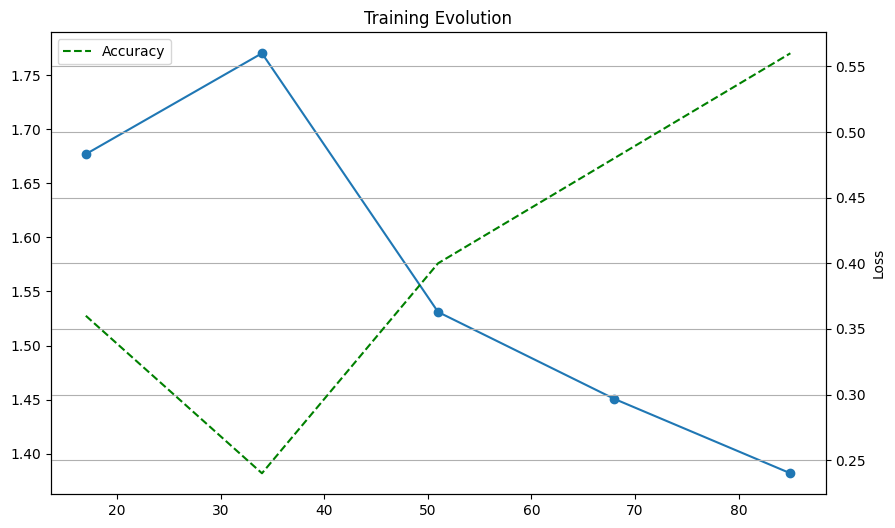

Device set to use cuda:0



--- Confusion Table ---
Predicted           Leveringsproblemer  Produktkvalitet  Troværdighed
Actual                                                               
Kundeservice                         0                4             1
Leveringsproblemer                   2                0             0
Prissætning                          0                1             1
Produktkvalitet                      0                5             4
Troværdighed                         1                1             5

--- Global Performance ---
Total Accuracy: 48.00%
Macro Precision: 31.52%
Macro Recall: 45.40%
Macro F1-score: 37.11%

--- Detailed Metrics per Category ---
                    precision    recall  f1-score   support

      Kundeservice       0.00      0.00      0.00         5
Leveringsproblemer       0.67      1.00      0.80         2
       Prissætning       0.00      0.00      0.00         2
   Produktkvalitet       0.45      0.56      0.50         9
      Troværdighed       0

c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torc

In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset # Huggingface's specialized version for it's models

column_to_use = "model_input"
column_to_use = "review_text"

def finetune_bert(model_name):
    # Split the data (75% Train, 25% Test)
    train_df, test_df = train_test_split(df_labeled, test_size=0.25, random_state=42)

    # Oversample only train_df
    train_df_balanced = balance_dataset(train_df)
    print("Class distribution after oversampling:")
    print(train_df_balanced['label'].value_counts())
    print(train_df_balanced.shape)
    
    # Setup Label Mappings
    labels = sorted(df_labeled['label'].unique().tolist())
    label2id = {label: i for i, label in enumerate(labels)}
    id2label = {i: label for i, label in enumerate(labels)}

    # Load Model and Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=len(labels),
        id2label=id2label,
        label2id=label2id
    ).to("cuda")

    # Tokenization Function
    def tokenize_function(examples):
        return tokenizer(examples[column_to_use], padding="max_length", truncation=True, max_length=512)

    # Prepare Datasets
    def prepare_ds(df):
        ds = Dataset.from_pandas(df[[column_to_use, 'label']].copy())
        # Map text labels to IDs
        ds = ds.map(lambda x: {"label": label2id[x["label"]]}, remove_columns=["label"])
        return ds.map(tokenize_function, batched=True)

    # train_dataset = prepare_ds(train_df)
    train_dataset = prepare_ds(train_df_balanced)
    test_dataset = prepare_ds(test_df)

    # Training Arguments (Fixed eval_strategy)
    training_args = TrainingArguments(
        output_dir="./bert_results",
        learning_rate=5e-5, # 2e-5
        per_device_train_batch_size=8, 
        num_train_epochs=5, # 3
        weight_decay=0.01,
        eval_strategy="epoch",  
        save_strategy="epoch",
        metric_for_best_model="accuracy", 
        greater_is_better=True,
        load_best_model_at_end=True,
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = torch.argmax(torch.tensor(logits), dim=-1)
        return {"accuracy": (predictions == torch.tensor(labels)).float().mean().item()}
    
    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    # Train
    trainer.train()

    # Plot evolution
    plot_training_evolution(trainer.state.log_history)

    # EVALUATE
    model.eval()

    # Create classifier from the newly trained model
    bert_classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

    # Predict on the TEST set only
    test_df['bert_final_label'] = test_df[column_to_use].apply(lambda x: bert_classifier(x[:512])[0]['label'])

    # Final Evaluation
    bertft_metrics = evaluate_model(test_df['label'], test_df['bert_final_label'])

    return bertft_metrics

# Run
clear_gpu_memory()
bertft_us_metrics = finetune_bert("google-bert/bert-base-multilingual-cased")


### 2.2 Using: "Maltehb/danish-bert-botxo"

Synchronizing hardware states...
Remaining allocated: 17.25 MB
Remaining reserved: 42.00 MB
*** GPU memory should now be free ***
Class distribution after oversampling:
label
Prissætning             22
Produktkvalitet         22
Kundeservice            22
Leveringsproblemer      22
Troværdighed            22
Retur og refundering    22
Name: count, dtype: int64
(132, 9)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Maltehb/danish-bert-botxo and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 25/25 [00:00<00:00, 3474.06 examples/s]
C:\Users\claud\AppData\Local\Temp\ipykernel_7608\2874278964.py:67: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.655212,0.320000
2,No log,1.627854,0.320000
3,No log,1.438214,0.440000
4,No log,1.445902,0.400000
5,No log,1.398431,0.480000


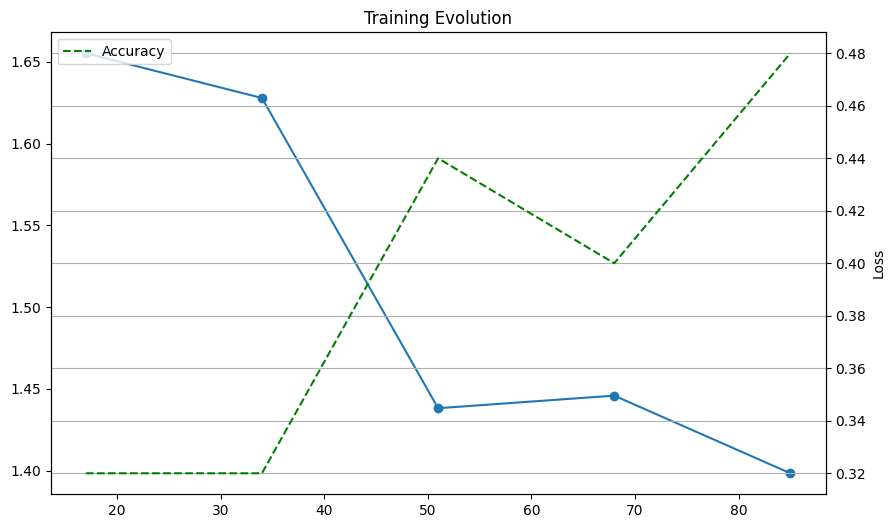

Device set to use cuda:0



--- Confusion Table ---
Predicted           Kundeservice  Leveringsproblemer  Produktkvalitet  \
Actual                                                                  
Kundeservice                   5                   0                0   
Leveringsproblemer             0                   2                0   
Prissætning                    0                   1                0   
Produktkvalitet                3                   0                1   
Troværdighed                   2                   1                0   

Predicted           Retur og refundering  Troværdighed  
Actual                                                  
Kundeservice                           0             0  
Leveringsproblemer                     0             0  
Prissætning                            0             1  
Produktkvalitet                        1             4  
Troværdighed                           0             4  

--- Global Performance ---
Total Accuracy: 48.00%
Macro Precisi

c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torch_env312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\claud\torch_env312

In [22]:
clear_gpu_memory()
bertft_da_metrics = finetune_bert("Maltehb/danish-bert-botxo")

### Report

In [23]:
# Order
column_metrics = ["Precision", "Recall", "F1 Score", "Accuracy"]

# Dictionary to convert into Panda's dataframe
data = {
    "NLI Model": nli_metrics,
    "LLM Zero-Shot": llm_metrics,
    "LLM Few-Shot": llmfs_metrics,
    "Bert Finetune English": bertft_us_metrics,
    "Bert Finetune Danish": bertft_da_metrics
}

# Convert and Transpose
df_results = pd.DataFrame(data, index=column_metrics).T

# Print table with 4 decimals
print("--- Model Comparison ---")
print(df_results.round(4))

--- Model Comparison ---
                       Precision  Recall  F1 Score  Accuracy
NLI Model                 0.6392  0.4125    0.3753      0.49
LLM Zero-Shot             0.3825  0.3731    0.2821      0.42
LLM Few-Shot              0.7379  0.6702    0.6487      0.66
Bert Finetune English     0.3152  0.4540    0.3711      0.48
Bert Finetune Danish      0.4074  0.4471    0.3389      0.48
